# Week 4: Logistic Regression (Bank Marketing - UCI)- Instructor notebook

> ```
> -In this notebook, you will walk through a standard machine-learning workflow for logistic regression on the UCI Bank Marketing dataset.
> -Why does this matter?
>     1. LR will be your baseline model in many Machine Learning projects, and you should be familiar with the entire process.
>     2. Getting comfortable with this learning algorithm will facilitate your understanding of the more complex ones.
> ```

In [15]:
# Imports
import pandas as pd
import numpy as np
import plotly.express as px
import warnings; warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve, precision_recall_curve, confusion_matrix, classification_report)

# Reproducibility
RANDOM_STATE = 42

## 1. Load & Inspect

In [16]:
df_bank = pd.read_csv("bank-additional.csv", sep=';')

display(df_bank.head())
df_bank.info()
print("\nRelevant numeric variables statistics:\n", df_bank.select_dtypes(exclude=object).describe())
print("\nMissing values per column:\n", df_bank.isna().sum())
print("\nCorrelation matrix ('age','duration','campaign','pdays','previous','emp.var.rate','cons.price.idx','cons.conf.idx','euribor3m','nr.employed'):\n", 
      df_bank[['age','duration','campaign','pdays','previous','emp.var.rate','cons.price.idx','cons.conf.idx','euribor3m','nr.employed']].corr())

FileNotFoundError: [Errno 2] No such file or directory: 'bank-additional.csv'

## 2. Define target & features
1. Convert `y` from 'yes'/'no' to 1/0.
2. Drop **`duration`** (data leakage -> Don't use information during training that wouldn't exist at prediction time).
3. Split with **stratification** to keep class balance (ensures both train and test datasets preserve the same positive/negative ratio).
4. Identify categorical vs. numeric columns.

In [ ]:
# 1. Convert target to binary
df = df_bank.copy()
df['y'] = (df['y'] == 'yes').astype(int)

display(df[['y']].describe())  # 11% of customers subscribed +> Dataset is imbalanced.
print("\nCorrelation matrix ('y','age','duration','campaign','pdays','previous','emp.var.rate','cons.price.idx','cons.conf.idx','euribor3m','nr.employed'):\n", 
      df[['y','age','duration','campaign','pdays','previous','emp.var.rate','cons.price.idx','cons.conf.idx','euribor3m','nr.employed']].corr())

,y
count,4119.000000
mean,0.109493
std,0.312294
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000



Correlation matrix ('y','age','duration','campaign','pdays','previous','emp.var.rate','cons.price.idx','cons.conf.idx','euribor3m','nr.employed'):
                        y       age  duration  campaign     pdays  previous  \
y               1.000000  0.060374  0.418565 -0.076091 -0.332012  0.255697   
age             0.060374  1.000000  0.041299 -0.014169 -0.043425  0.050931   
duration        0.418565  0.041299  1.000000 -0.085348 -0.046998  0.025724   
campaign       -0.076091 -0.014169 -0.085348  1.000000  0.058742 -0.091490   
pdays          -0.332012 -0.043425 -0.046998  0.058742  1.000000 -0.587941   
previous        0.255697  0.050931  0.025724 -0.091490 -0.587941  1.000000   
emp.var.rate   -0.283216 -0.019192 -0.028848  0.176079  0.270684 -0.415238   
cons.price.idx -0.098326 -0.000482  0.016672  0.145021  0.058472 -0.164922   
cons.conf.idx   0.054393  0.098135 -0.034745  0.007882 -0.092090 -0.051420   
euribor3m      -0.298565 -0.015033 -0.032329  0.159435  0.301478 -0.458

In [12]:
# 2. Drop known leakage feature
X = df.drop(columns=['y','duration'], errors='ignore')
y = df['y']

In [13]:
# 3. Train/test split (hold-out)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

In [14]:
# 4. Separate dtypes for preprocessing steps
cat_cols = [c for c in X.columns if X[c].dtype == 'object']
num_cols = [c for c in X.columns if c not in cat_cols]

print('Train shape:', X_train.shape, ' Test shape:', X_test.shape)
print('Train positive rate:', y_train.mean().round(4), ' Test positive rate:', y_test.mean().round(4))

Train shape: (3295, 19)  Test shape: (824, 19)
Train positive rate: 0.1096  Test positive rate: 0.1092


## 3. Pipeline & Cross-Validation (Lasso-L1/Ridge-L2/ElasticNet)
1. **OneHotEncoder** for categorical; **StandardScaler** for numeric.
2. `LogisticRegression(solver='saga')` supports **L1**, **L2**, **ElasticNet**.
3. **Pipeline** ties preprocessing to the model (avoids leakage, safe, reproducible).
4. Use **GridSearchCV (5-fold stratified)** and **average_precision** scoring (optimize PR-AUC, which is better than accuracy for imbalanced data).

In [15]:
# ?LogisticRegression

In [16]:
# 1. Preprocessing: one-hot for categoricals and scale numeric features
preprocess = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ('num', StandardScaler(), num_cols)
])

In [17]:
# 2. Logistic Regression base model
log_base = LogisticRegression(
    solver='saga',              # supports L1/L2/ElasticNet
    max_iter=3000,              # allow enough iterations to converge
    class_weight='balanced',    # simple imbalance handling
    n_jobs=-1,                  # use available cores
    random_state=RANDOM_STATE
)

In [18]:
# 3. Full pipeline: preprocess -> classifier
pipe = Pipeline([
    ('preprocess', preprocess),
    ('clf', log_base)
])

In [20]:
# 4. Hyperparameter grid: penalties + C values (+ l1_ratio for ElasticNet)
param_grid = [
    {'clf__penalty': ['l2'], 'clf__C': [0.01, 0.1, 1.0, 3.0, 10.0]},
    {'clf__penalty': ['l1'], 'clf__C': [0.01, 0.1, 1.0, 3.0, 10.0]},
    {'clf__penalty': ['elasticnet'], 'clf__l1_ratio': [0.1, 0.5, 0.9], 'clf__C': [0.01, 0.1, 1.0, 3.0, 10.0]},
]

# 5-fold CV, shuffle for stability, optimize PR AUC (average precision)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid = GridSearchCV(
    pipe, param_grid=param_grid, scoring='average_precision',
    cv=cv, n_jobs=-1, refit=True, verbose=1
)

grid.fit(X_train, y_train)             # Run the full grid search with CV.
best_model = grid.best_estimator_      # Extracts the final, refitted model.
print('Best params:', grid.best_params_)
print('Best CV PR AUC:', round(grid.best_score_, 4))

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best params: {'clf__C': 0.1, 'clf__l1_ratio': 0.5, 'clf__penalty': 'elasticnet'}
Best CV PR AUC: 0.4329


## 4. Evaluate on the test set
- Use the **hold-out test set** for an unbiased estimate.
- Report **ROC AUC** and **PR AUC**.

In [21]:
# Predicted probabilities for the positive class
proba_test = best_model.predict_proba(X_test)[:, 1]        #Provide the true predicted probabilities for the positive class in the test dataset, not the log-odds!!!!

# Compute ROC curve (Receiver Operating Characteristic) & AUC (Area Under the ROC Curve):
    # y-axis: True Positive Rate (TPR = Recall = TP/(TP+FN)).
    # x-axis: False Positive Rate (FPR = FP/(FP+TN)).
    # Each point on the ROC curve corresponds to a threshold used to classify probabilities into 0 and 1.
    # AUC evaluates how well a model separates the positive and negative classes (1:perfect classifier, 0.5:random guessing).
    # Best use when class balance is roughly even, or when FP and FN are equally costly.
print('Test ROC AUC:', round(roc_auc_score(y_test, proba_test), 4))

# Compute PR curve (Precision-Recall) or Average Precision.
    # y-axis: Precision = TP/(TP+FP)
                # Measures the accuracy of the positive predictions made by the model.
                # Measures how many of the instances that the model predicted as positive are actually positive.
    # x-axis: Recall = TP/(TP+FN)
                # Measures the completeness of the positive predictions made by the model.
                # Measures how many of the actual positive instances the model correctly identified. 
    # Each point on the PR curve corresponds to a threshold used to classify probabilities into 0 and 1.
    # Evaluates model's ability to identify true positives without too many false alarms, focusing on the positive class (0-1, higher is better).
    # Best use when positives are rare (e.g., fraud detection, disease diagnosis, lead conversion) and when FP are costly.   
print('Test PR  AUC:', round(average_precision_score(y_test, proba_test), 4))

# Best CV PR AUC: 0.4329 & Test PR  AUC: 0.4365 are very similar => The model is generalizing well, no overfitting, consistent.

Test ROC AUC: 0.795
Test PR  AUC: 0.4365


## 5. Curves (ROC and Precision–Recall)

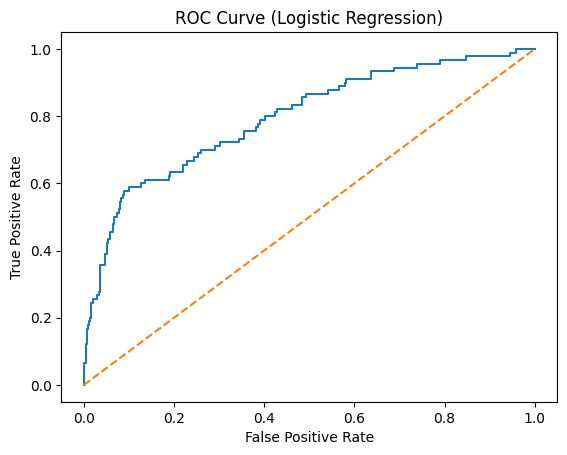

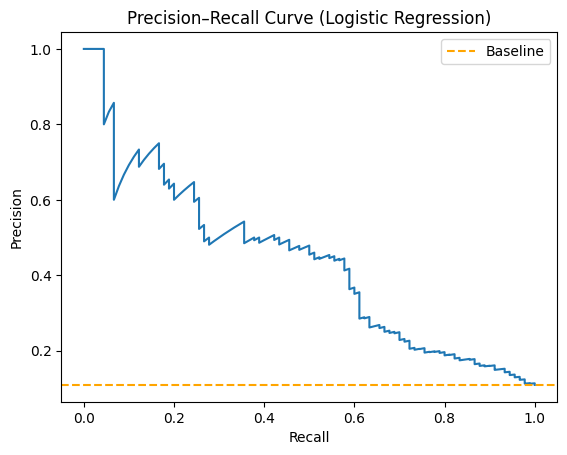

In [22]:
# Compute curve points
fpr, tpr, _ = roc_curve(y_test, proba_test)
prec, rec, _ = precision_recall_curve(y_test, proba_test)

# ROC curve
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')      # Represents random classifier
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Logistic Regression)')
plt.show()

# PR curve
plt.figure()
plt.plot(rec, prec)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision–Recall Curve (Logistic Regression)')
plt.axhline(y=y_test.mean(), color='orange', linestyle='--', label='Baseline') # A random classifier would achieve ~11% precision regardless of recall.
plt.legend()
plt.show()

## 6. Threshold choices (0.5 and Top-30%) - Converting predicted probabilities into hard probabilities (0 or 1)

In [23]:
# Confusion Matrix has 4 cells representing a combination of the predicted and actual class labels:
    # -True Negative (TN): Models correctly predicts the negative class.
    # -False Positive (FP): Models incorrectly predicts the positive class.
    # -False Negative (FN): Models incorrectly predicts the negative class.
    # -True Positive (TP): Models correctly predicts the positive class.


# Threshold = 0.5 (classic baseline, but it's not optimal for imbalanced datasets because we will predict almost all zeros = 633+35, high accuracy because 90% are no, but poor recall for positives).
pred_05 = (proba_test >= 0.5).astype(int)
print('== Threshold 0.5 ==')
print(classification_report(y_test, pred_05, digits=4))
print('Confusion matrix:\n', confusion_matrix(y_test, pred_05))

== Threshold 0.5 ==
              precision    recall  f1-score   support

           0     0.9476    0.8624    0.9030       734
           1     0.3526    0.6111    0.4472        90

    accuracy                         0.8350       824
   macro avg     0.6501    0.7368    0.6751       824
weighted avg     0.8826    0.8350    0.8532       824

Confusion matrix:
 [[633 101]
 [ 35  55]]


In [24]:
# Top-30% by probability (capacity-based, business-oriented approach) -> Pick the top 30% most likely to convert.
k = int(len(proba_test) * 0.30)                              # How many samples represent 30% of the test size?
cut = np.partition(proba_test, -k)[-k] if k > 0 else 1.0     # Find the probability cutoff that separates the top 30% from the rest.
pred_top30 = (proba_test >= cut).astype(int)                 # Select predicted probability only for top 30%.
print('\n== Top-30% ==')
print('Cutoff ≈', round(float(cut), 4))
print(classification_report(y_test, pred_top30, digits=4))
print('Confusion matrix:\n', confusion_matrix(y_test, pred_top30))

# Expectation: Higher recall, Lower precision.


== Top-30% ==
Cutoff ≈ 0.4122
              precision    recall  f1-score   support

           0     0.9497    0.7466    0.8360       734
           1     0.2470    0.6778    0.3620        90

    accuracy                         0.7391       824
   macro avg     0.5984    0.7122    0.5990       824
weighted avg     0.8730    0.7391    0.7842       824

Confusion matrix:
 [[548 186]
 [ 29  61]]


## 7. Lift & Gains (deciles)
Very common in lead scoring to show business value quickly.

In [25]:
# Build deciles by sorting on predicted probability (test set only)
df_eval = pd.DataFrame({'y': y_test.values, 'proba': proba_test})                                      # True labels (y_test) and the predicted probabilities (proba_test).
df_eval = df_eval.sort_values('proba', ascending=False).reset_index(drop=True)                         # The most confident positive predictions are at the top (high probability), and the least confident at the bottom.
df_eval['decile'] = pd.qcut(df_eval.index + 1, 10, labels=False) + 1                                   # Create deciles.

overall_rate = df_eval['y'].mean()                                                                     # Base line conversion rate.
dec_summary = df_eval.groupby('decile').agg(leads=('y','size'), positives=('y','sum')).reset_index()   # For each decile, count total leads and how many positive.
dec_summary['rate'] = dec_summary['positives']/dec_summary['leads']                                    # Decile conversion rate.    
dec_summary['lift'] = dec_summary['rate']/overall_rate                                                 # Lift = Decile conversion rate / Base line conversion rate.
dec_summary['cum_pos'] = dec_summary['positives'].cumsum()                                             # Sum of all positives.
dec_summary['cum_pct_pos'] = dec_summary['cum_pos']/dec_summary['positives'].sum()                     # % of all positives captured as you expand capacity.
dec_summary['cum_pct_leads'] = dec_summary['leads'].cumsum()/dec_summary['leads'].sum()                # % of leads contacted.
print('Overall positive rate:', round(overall_rate,4))
dec_summary.head()

Overall positive rate: 0.1092


,decile,leads,positives,rate,lift,cum_pos,cum_pct_pos,cum_pct_leads
0,1,83,41,0.493976,4.522624,41,0.455556,0.100728
1,2,82,14,0.170732,1.563144,55,0.611111,0.200243
2,3,82,6,0.073171,0.669919,61,0.677778,0.299757
3,4,83,7,0.084337,0.772155,68,0.755556,0.400485
4,5,82,6,0.073171,0.669919,74,0.822222,0.500000


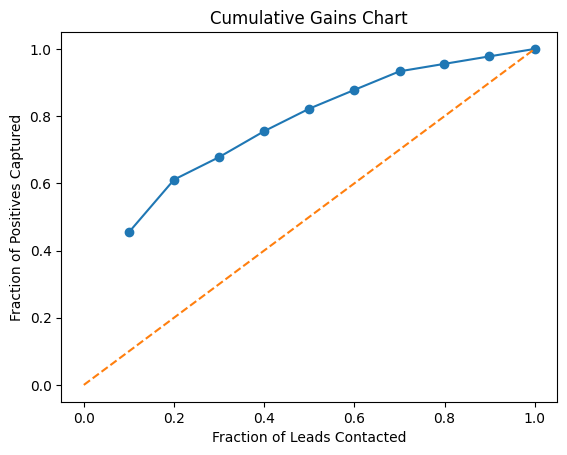

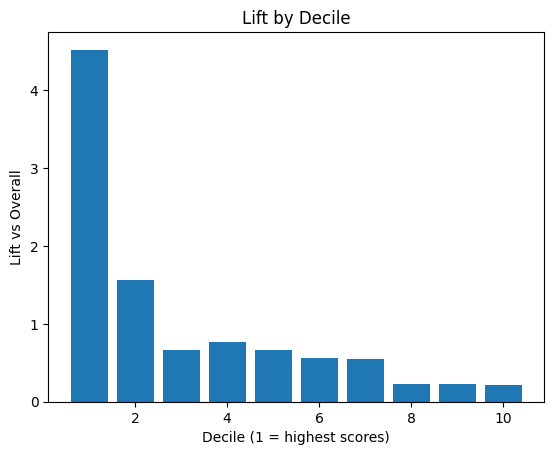

In [26]:
# Plot cumulative gains
plt.figure()
plt.plot(dec_summary['cum_pct_leads'], dec_summary['cum_pct_pos'], marker='o')
plt.plot([0,1],[0,1],'--')
plt.xlabel('Fraction of Leads Contacted')
plt.ylabel('Fraction of Positives Captured')
plt.title('Cumulative Gains Chart')
plt.show()

# Plot lift by decile
plt.figure()
plt.bar(dec_summary['decile'], dec_summary['lift'])
plt.xlabel('Decile (1 = highest scores)')
plt.ylabel('Lift vs Overall')
plt.title('Lift by Decile')
plt.show()

# 🧪 Student Exercises
Change the values in the code cells and re-run the related section. Keep notes on what changed and why.

## Exercise 1 — Capacity sweep (Top-k%)
In Section **6) Threshold choices**, we used **Top-30%**.
1. Try **Top-10%** and **Top-20%** and compare **precision**/**recall**.
2. Which k% gives the best balance for your (imaginary) team capacity?
3. Bonus: Use the **decile table** in Section 7 to estimate how many positives you expect if you contact the top 2 or 3 deciles.

## Exercise 2 — Compare L1 vs L2 vs ElasticNet
1. Re-run the CV in Section **3)** three times, **restricting** `param_grid` to only **L1**, then only **L2**, then only **ElasticNet**.
2. Record the best `C` (and `l1_ratio` for ElasticNet) and **CV PR AUC** for each.
3. Which penalty won?